<center><img src="https://www.googleapis.com/download/storage/v1/b/kaggle-user-content/o/inbox%2F4895752%2Fbf6d1be3b18ade8bd780840fd8f871c1%2FU78nzyG.jpg?generation=1597522833435019&alt=media" width="1100" height="300"></center>

# <center>"Live Coding" Session - Introduction To Machine Learning</center>
### <center>Digital Sciences For Hi-Tech - 2026</center>
#### <center>Liav Amir</center>

in this session we will go through the steps of executing a data science project using CRISP-DM (Cross Industry Standard Process for Data Mining). This method includes the following steps:
1. Buisness Uderstanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation
6. Deployment (Won't be used in this session nor your project)

We'll use the "csgo round winner classification" Dataset:

https://www.kaggle.com/datasets/christianlillelund/csgo-round-winner-classification

short description about the game (taken from the kaggle  dataset page):

*"CS:GO is a tactical shooter, where two teams (CT and Terrorist) play for a best of 30 rounds, with each round being 1 minute and 55 seconds. There are 5 players on each team (10 in total) and the first team to reach 16 rounds wins the game. At the start, one team plays as CT and the other as Terrorist. After 15 rounds played, the teams swap side. There are 7 different maps a game can be played on. You win a round as Terrorist by either planting the bomb and making sure it explodes, or by eliminating the other team. You win a round as CT by either eliminating the other team, or by disarming the bomb, should it have been planted".*

**Our goal is to predict the winner of the current round (T- Terrorists or CT- Counter Terrorists) while given a snapshot of the current situation of the game.**





First, we would import the required libraries in the first cell of the notebook in order to keep the notebook tidy as possible:

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import RocCurveDisplay

# Remove warnings
import sys
import warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")

Now, we should import the csv we've working on in order to start understanding our dataset:

In [ ]:
data = pd.read_csv("csgo_round_snapshots.csv")
pd.set_option("display.max_columns", None) # The None parameter cancelling the limit of the max coloumns shown.
data.head()

,time_left,ct_score,t_score,map,bomb_planted,ct_health,t_health,ct_armor,t_armor,ct_money,t_money,ct_helmets,t_helmets,ct_defuse_kits,ct_players_alive,t_players_alive,ct_weapon_ak47,t_weapon_ak47,ct_weapon_aug,t_weapon_aug,ct_weapon_awp,t_weapon_awp,ct_weapon_bizon,t_weapon_bizon,ct_weapon_cz75auto,t_weapon_cz75auto,ct_weapon_elite,t_weapon_elite,ct_weapon_famas,t_weapon_famas,ct_weapon_g3sg1,t_weapon_g3sg1,ct_weapon_galilar,t_weapon_galilar,ct_weapon_glock,t_weapon_glock,ct_weapon_m249,t_weapon_m249,ct_weapon_m4a1s,t_weapon_m4a1s,ct_weapon_m4a4,t_weapon_m4a4,ct_weapon_mac10,t_weapon_mac10,ct_weapon_mag7,t_weapon_mag7,ct_weapon_mp5sd,t_weapon_mp5sd,ct_weapon_mp7,t_weapon_mp7,ct_weapon_mp9,t_weapon_mp9,ct_weapon_negev,t_weapon_negev,ct_weapon_nova,t_weapon_nova,ct_weapon_p90,t_weapon_p90,ct_weapon_r8revolver,t_weapon_r8revolver,ct_weapon_sawedoff,t_weapon_sawedoff,ct_weapon_scar20,t_weapon_scar20,ct_weapon_sg553,t_weapon_sg553,ct_weapon_ssg08,t_weapon_ssg08,ct_weapon_ump45,t_weapon_ump45,ct_weapon_xm1014,t_weapon_xm1014,ct_weapon_deagle,t_weapon_deagle,ct_weapon_fiveseven,t_weapon_fiveseven,ct_weapon_usps,t_weapon_usps,ct_weapon_p250,t_weapon_p250,ct_weapon_p2000,t_weapon_p2000,ct_weapon_tec9,t_weapon_tec9,ct_grenade_hegrenade,t_grenade_hegrenade,ct_grenade_flashbang,t_grenade_flashbang,ct_grenade_smokegrenade,t_grenade_smokegrenade,ct_grenade_incendiarygrenade,t_grenade_incendiarygrenade,ct_grenade_molotovgrenade,t_grenade_molotovgrenade,ct_grenade_decoygrenade,t_grenade_decoygrenade,round_winner
0,175.00,0,0,de_dust2,False,500,500,0,0,4000,4000,0.0,0,0,5,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,CT
1,156.03,0,0,de_dust2,False,500,500,400,300,600,650,0.0,0,1,5,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,1,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,CT
2,96.03,0,0,de_dust2,False,391,400,294,200,750,500,NaN,0,1,4,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,CT
3,76.03,0,0,de_dust2,False,391,400,294,200,750,500,NaN,0,1,4,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,CT
4,174.97,1,0,de_dust2,False,500,500,192,0,18350,10750,NaN,0,1,5,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,CT


After making sure the dataset is presented in the right format in the notebook, we should start investigate about the data itself:

In [ ]:
data.shape

(122410, 97)

We can see that we have 122,410 rows and 97 columns.
In order to prevent data leakage and overfitting, we'll split the data into test and train dataset in this stage of the project. We'll use 80/20 split (80% of the dataset will be under the train set and the remaining 20% of the data will be under the test set):

In [ ]:
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)

print(f"The train_data shape is: {train_data.shape}")
print(f"The test_data shape is: {test_data.shape}")

The train_data shape is: (97928, 97)
The test_data shape is: (24482, 97)


After spliting the data into train and test set, we'll use the describe function and the info function in order to get more information about our dataset:

In [ ]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 97928 entries, 46932 to 121958
Data columns (total 97 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   time_left                     97928 non-null  float64
 1   ct_score                      97928 non-null  int64  
 2   t_score                       97928 non-null  int64  
 3   map                           97928 non-null  object 
 4   bomb_planted                  97928 non-null  bool   
 5   ct_health                     97928 non-null  int64  
 6   t_health                      97928 non-null  int64  
 7   ct_armor                      97928 non-null  int64  
 8   t_armor                       97928 non-null  int64  
 9   ct_money                      97928 non-null  int64  
 10  t_money                       97928 non-null  int64  
 11  ct_helmets                    97887 non-null  float64
 12  t_helmets                     97928 non-null  int64  
 13  c

The info() function shows the type of each of the columns and the number of non-null values in each columns. We can see that almost all of our columns are numeric (number based), while the only categorical data columns we have in this dataset is the map column, the bomb_planted columns (can also be viewed as 0 and 1) and the round_winner column which is also our label column. We'll think about the ways of handling the map column later. For now, let's replace the bomb_planted and the round_winner columns with 0 and 1:

In [ ]:
train_data["round_winner"] = train_data["round_winner"].replace({"CT":1,"T":0})
train_data["bomb_planted"] = train_data["bomb_planted"].astype(int)

/tmp/ipykernel_12642/3021505883.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_data["round_winner"] = train_data["round_winner"].replace({"CT":1,"T":0})


We can also see that all of the columns in the dataset is without any missing values, except the "ct_helmets" column, which shows us the number of helmets the counter terrorists (CT) team has.  
We'll check the number of missing values using the following code:

In [ ]:
train_data.isna().sum().to_frame(name ="number_of_missing_values").sort_values("number_of_missing_values", ascending=False)

,number_of_missing_values
ct_helmets,41
time_left,0
ct_score,0
map,0
t_score,0
...,...
ct_grenade_molotovgrenade,0
t_grenade_molotovgrenade,0
ct_grenade_decoygrenade,0
t_grenade_decoygrenade,0


In [ ]:
train_data.describe()

,time_left,ct_score,t_score,bomb_planted,ct_health,t_health,ct_armor,t_armor,ct_money,t_money,ct_helmets,t_helmets,ct_defuse_kits,ct_players_alive,t_players_alive,ct_weapon_ak47,t_weapon_ak47,ct_weapon_aug,t_weapon_aug,ct_weapon_awp,t_weapon_awp,ct_weapon_bizon,t_weapon_bizon,ct_weapon_cz75auto,t_weapon_cz75auto,ct_weapon_elite,t_weapon_elite,ct_weapon_famas,t_weapon_famas,ct_weapon_g3sg1,t_weapon_g3sg1,ct_weapon_galilar,t_weapon_galilar,ct_weapon_glock,t_weapon_glock,ct_weapon_m249,t_weapon_m249,ct_weapon_m4a1s,t_weapon_m4a1s,ct_weapon_m4a4,t_weapon_m4a4,ct_weapon_mac10,t_weapon_mac10,ct_weapon_mag7,t_weapon_mag7,ct_weapon_mp5sd,t_weapon_mp5sd,ct_weapon_mp7,t_weapon_mp7,ct_weapon_mp9,t_weapon_mp9,ct_weapon_negev,t_weapon_negev,ct_weapon_nova,t_weapon_nova,ct_weapon_p90,t_weapon_p90,ct_weapon_r8revolver,t_weapon_r8revolver,ct_weapon_sawedoff,t_weapon_sawedoff,ct_weapon_scar20,t_weapon_scar20,ct_weapon_sg553,t_weapon_sg553,ct_weapon_ssg08,t_weapon_ssg08,ct_weapon_ump45,t_weapon_ump45,ct_weapon_xm1014,t_weapon_xm1014,ct_weapon_deagle,t_weapon_deagle,ct_weapon_fiveseven,t_weapon_fiveseven,ct_weapon_usps,t_weapon_usps,ct_weapon_p250,t_weapon_p250,ct_weapon_p2000,t_weapon_p2000,ct_weapon_tec9,t_weapon_tec9,ct_grenade_hegrenade,t_grenade_hegrenade,ct_grenade_flashbang,t_grenade_flashbang,ct_grenade_smokegrenade,t_grenade_smokegrenade,ct_grenade_incendiarygrenade,t_grenade_incendiarygrenade,ct_grenade_molotovgrenade,t_grenade_molotovgrenade,ct_grenade_decoygrenade,t_grenade_decoygrenade,round_winner
count,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97887.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.0,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.0,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.0,97928.0,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.0,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.0,97928.000000,97928.0,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.000000,97928.00000,97928.000000
mean,97.855293,6.704865,6.780165,0.111756,412.081529,402.607742,314.168175,298.496477,9789.311024,11238.755514,2.055554,2.774508,1.614349,4.274314,4.265624,0.274487,1.244864,0.134252,0.007475,0.573513,0.321124,0.0,0.000092,0.151816,0.106262,0.004217,0.001961,0.109917,0.004616,0.0,0.000705,0.011294,0.110173,0.006821,3.304275,0.0,0.0,0.063281,0.002798,1.076240,0.053192,0.007822,0.107977,0.004401,0.000041,0.001460,0.002818,0.002093,0.001859,0.147905,0.005708,0.0,0.000010,0.001001,0.000092,0.000184,0.000112,0.0,0.000061,0.0,0.000133,0.000745,0.000010,0.239676,0.823544,0.059983,0.020883,0.046371,0.036782,0.007526,0.000276,0.441814,0.384027,0.061770,0.009578,3.179091,0.123029,0.237195,0.292409,0.173719,0.005096,0.008200,0.028623,0.900141,0.438894,1.851667,1.858998,1.540428,1.628360,1.002400,0.019841,0.047954,1.351064,0.028123,0.02558,0.490156
std,54.447093,4.787643,4.823268,0.315067,132.293031,140.022493,170.941890,174.523579,11219.411639,12147.671452,1.842123,2.010091,1.605652,1.204812,1.229306,0.584814,1.363583,0.460007,0.090075,0.673203,0.476972,0.0,0.009586,0.445321,0.381014,0.064805,0.044236,0.387902,0.069859,0.0,0.034261,0.113589,0.406207,0.086425,1.626828,0.0,0.0,0.261664,0.053590,1.217412,0.247980,0.096399,0.413679,0.067570,0.006391,0.038186,

The describe function allows us to see the general details of each column. For example, we can see the max and min values in each column, the mean, median and the values of the different quartiles. This information allows us to understand the scale of the dataset and general properties like distribution etc...  
We can also see that many of the columns that include the word "weapon" are very sparse (Built from almost all zeros) and with small standard deviation that may suggest they are redundant.
Another thing we can see is that the "round_winner" column (The label column) is balanced, which mean that each team win in about 50% of the matches played.

After noticing the large group of sparse column we'll see the general disribution of the values of each column in the dataset using the hist function, which gives us an histogram for each column:

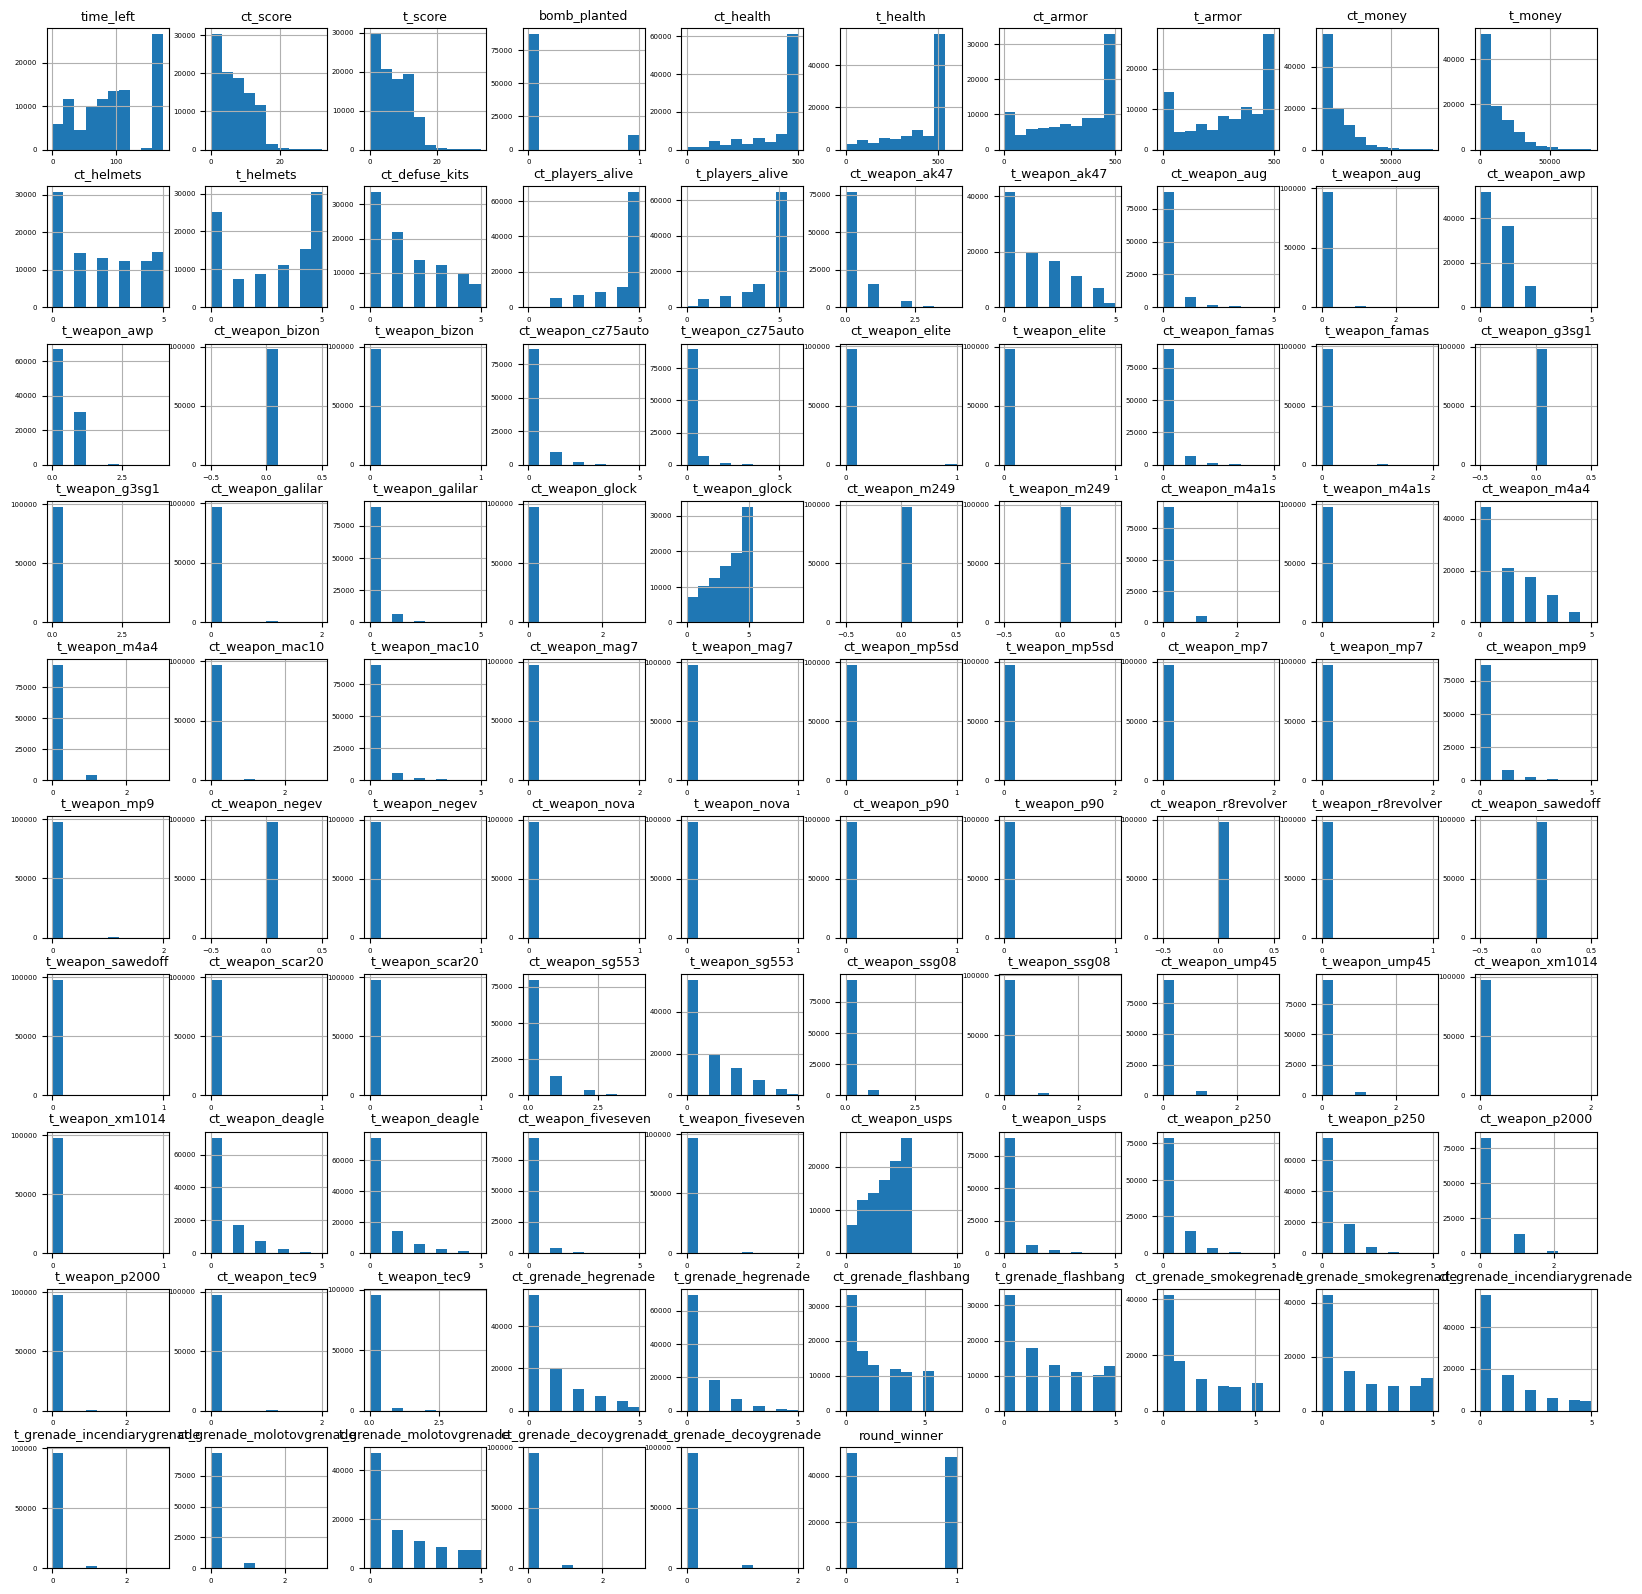

In [ ]:
plt.rcParams.update({"axes.titlesize": 9}) # We'll use this column in order to set the title sizes of each histogram
train_data.hist(figsize=(20,20), xlabelsize=5, ylabelsize=5);

This visualization shows us what we've seen in the describe function - that most of the "weapon" included column are sparse and probably doesn't give strong enough indication in order to use them for predicting the identity of the winning team.
We'll see exactly what is the percentage of zeros in these columns to be able to decide on what we should do:

In [ ]:
weapon_cols = train_data.filter(like="weapon").columns.to_list() # prepare a list of all the column name that has the word "weapon".
data_weapon = train_data[weapon_cols] # create a dataset with those columns and the label column.
zeros_pct = (data_weapon == 0).mean() * 100 # calculate the zeros percentage of each column in the "weapon" columns.

In [ ]:
zeros_pct.to_frame(name="zeros_percentage").sort_values("zeros_percentage", ascending=False)

,zeros_percentage
ct_weapon_m249,100.000000
t_weapon_m249,100.000000
ct_weapon_g3sg1,100.000000
ct_weapon_bizon,100.000000
ct_weapon_r8revolver,100.000000
...,...
ct_weapon_awp,52.875582
ct_weapon_m4a4,45.516093
t_weapon_ak47,42.478147
t_weapon_glock,7.363573


We should decide on the minimal threshold (percentage of zeros) to keep the column. We can use a line graph in order to do so:

/tmp/ipykernel_12642/1047488030.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


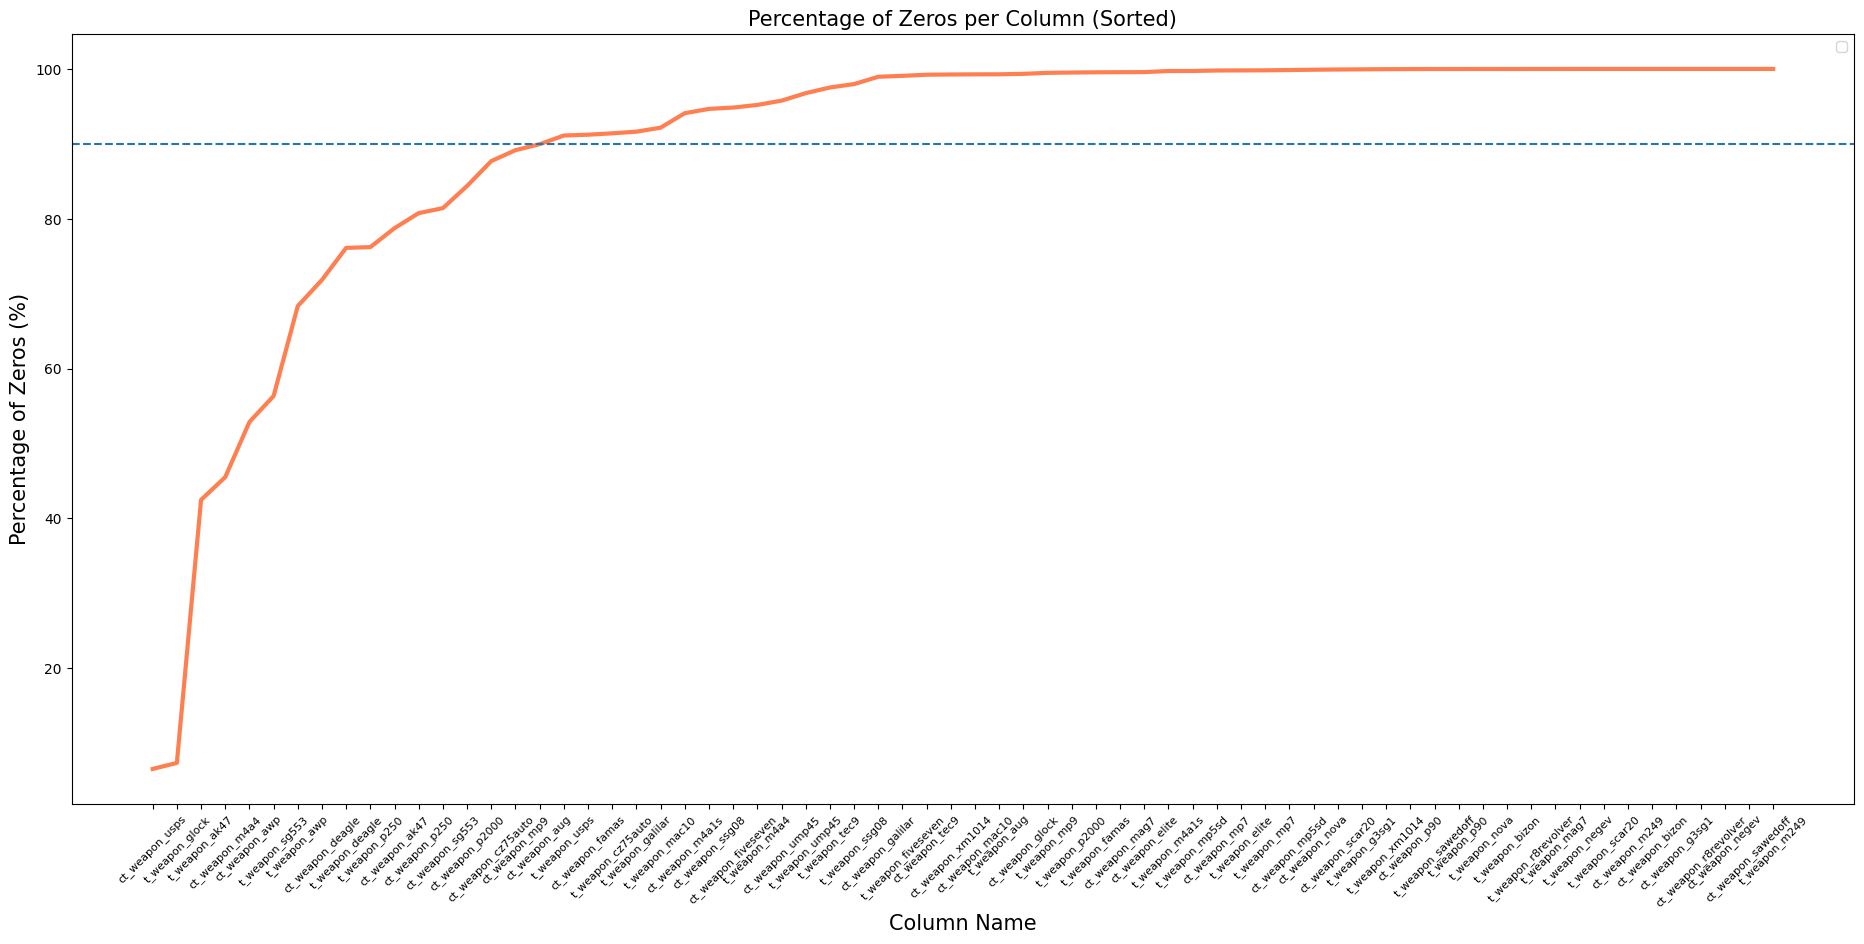

In [ ]:
zeros_sorted = zeros_pct.to_frame(name="zeros_percentage").sort_values("zeros_percentage", ascending=True)

plt.figure(figsize=(23, 10))
plt.plot(zeros_sorted, linewidth=3, color='coral')
plt.title('Percentage of Zeros per Column (Sorted)', fontsize=15)
plt.xlabel('Column Name', fontsize=15)
plt.xticks(rotation=45, fontsize=8)
plt.ylabel('Percentage of Zeros (%)', fontsize=15)
plt.axhline(y=90, ls="--")
plt.show()

It looks like a good threshold will be at 90% zeros (we can be more conservative and increase the threshold or be more liberal and reduce the threshold).
We'll create a list of the column names we want to remove so we could use that later while we perform the process on the validation set:

In [ ]:
zeros_sorted["zeros_percentage"]

,zeros_percentage
ct_weapon_usps,6.556858
t_weapon_glock,7.363573
t_weapon_ak47,42.478147
ct_weapon_m4a4,45.516093
ct_weapon_awp,52.875582
...,...
ct_weapon_g3sg1,100.000000
ct_weapon_r8revolver,100.000000
ct_weapon_negev,100.000000
ct_weapon_sawedoff,100.000000


In [ ]:
cols_to_remove = zeros_sorted[zeros_sorted["zeros_percentage"]>=90].index.tolist()
print(f"Number of column we chose to remove so far: {len(cols_to_remove)}\n")
print(cols_to_remove)

Number of column we chose to remove so far: 51

['t_weapon_usps', 'ct_weapon_famas', 't_weapon_cz75auto', 't_weapon_galilar', 't_weapon_mac10', 'ct_weapon_m4a1s', 'ct_weapon_ssg08', 'ct_weapon_fiveseven', 't_weapon_m4a4', 'ct_weapon_ump45', 't_weapon_ump45', 't_weapon_tec9', 't_weapon_ssg08', 'ct_weapon_galilar', 't_weapon_fiveseven', 'ct_weapon_tec9', 'ct_weapon_xm1014', 'ct_weapon_mac10', 't_weapon_aug', 'ct_weapon_glock', 't_weapon_mp9', 't_weapon_p2000', 't_weapon_famas', 'ct_weapon_mag7', 'ct_weapon_elite', 't_weapon_m4a1s', 't_weapon_mp5sd', 'ct_weapon_mp7', 't_weapon_elite', 't_weapon_mp7', 'ct_weapon_mp5sd', 'ct_weapon_nova', 'ct_weapon_scar20', 't_weapon_g3sg1', 't_weapon_xm1014', 'ct_weapon_p90', 't_weapon_sawedoff', 't_weapon_p90', 't_weapon_nova', 't_weapon_bizon', 't_weapon_r8revolver', 't_weapon_mag7', 't_weapon_negev', 't_weapon_scar20', 'ct_weapon_m249', 'ct_weapon_bizon', 'ct_weapon_g3sg1', 'ct_weapon_r8revolver', 'ct_weapon_negev', 'ct_weapon_sawedoff', 't_weapon_m249

We chose to remove **51 columns!!!** this will simplify our model and our data exploration step and help prevent overfitting.  
**Tip:** start by understanding the general picture of the data before diving into small details. Doing so might help you find massive part of the data that are redundant and save you a lot of time later on.

Another interesting thing is to understand that a lot of columns in the dataset show a "snapshot" of two teams with parallel columns for each team. Understanding this fact might help us find interesting visualizations that'll lead to conclusions in later steps of the process (For example, feature engineering).  
Let's take the ct_health and the t_health columns and see them side by side:

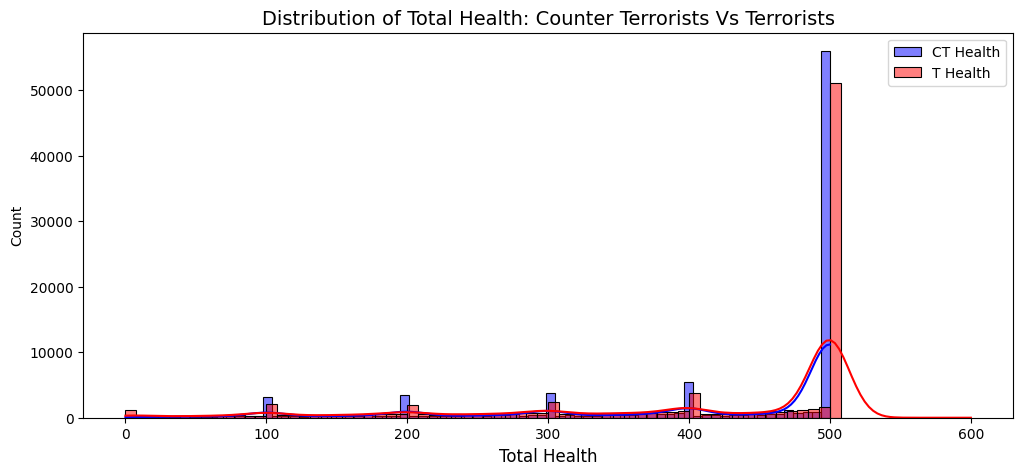

In [ ]:
plt.figure(figsize=(12,5))

sns.histplot(train_data["ct_health"], color="blue", label="CT Health", kde=True, alpha=0.5)
sns.histplot(train_data["t_health"], color="red", label="T Health", kde=True, alpha=0.5)

plt.title("Distribution of Total Health: Counter Terrorists Vs Terrorists", fontsize=14)
plt.xlabel("Total Health", fontsize=12)
plt.legend()

plt.show()

In this visualization, we can learn / speculate a few things:
1. At first glance, the Health feature for both the Counter Terrorists (CT) and the Terrorists looks similar to one another (makes sense). Because we have a massive "jump" in the 500 value range that distorts the visualization, we can't say that for sure.
2. Even though the feature distribution is similar, we can see that the Counter Terrorists are more common to have total health at the hundreds over the Terrorists, while the Terrorists are more common to have health not at the hundreds in relation to the Counter Terrorists.  
**Why is this happening?**  
After looking into this observation online, i saw that the CT team moves in smaller groups (2-1-2 formation) to guard A site, B site and mid, while the Terrorists group usually moves in larger groups, which gives them an advantage when small group ecounter larger one. This is why we see that the CT team has more cases when the total health is multiply of 100, because it shows incidents where the group that had the encounter was killed, while the larger Terrorist group lost some of its health (each team member), but not fully killed.
3. The Common 500 health value is probably related to the beginning state of the game (5 players in each team, where all 5 players start from 100 health).
4. We can see a "bump" in each 100's multiplication. It may happen because some of the players on the team had an encounter and were killed while the others haven't has an encounter yet.
5. Clear difference between the number of times the t_health is at 0 and the ct_health is at 0. Situation where the t_health is at 0 is much more common than situation where the ct_health is at 0. This is an anomaly in relation to the rest of the data. We'll look into it later.

There are some things that can't be seen using this plot:
1. Is there a correlation between the health of both teams in each observation ("snapshot") of the data set?
2. Is there a correlation between high health value and the win of the team in this round? Or is there another way to use the health feature to help us understand which team has the advantage?

In order to solve those mysteries, we'll start by changing the y scale of the graph (To Log scale) to be able to see better the distribution of both teams:

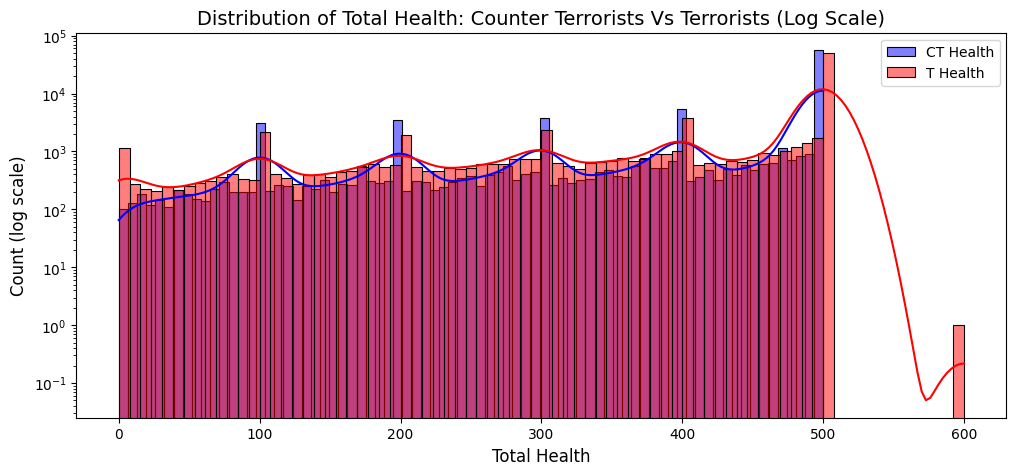

In [ ]:
plt.figure(figsize=(12,5))

sns.histplot(train_data["ct_health"], color="blue", label="CT Health", kde=True, alpha=0.5)
sns.histplot(train_data["t_health"], color="red", label="T Health", kde=True, alpha=0.5)

plt.title("Distribution of Total Health: Counter Terrorists Vs Terrorists (Log Scale)", fontsize=14)
plt.xlabel("Total Health", fontsize=12)
plt.legend()

plt.yscale("log")
plt.ylabel("Count (log scale)", fontsize=12)

plt.show()

Using this graph, we can see that this feature is indeed act a like in both teams. We can also see that we have one outlier in the "T_Health" column (Even though we have only 5 players in each team with maximum helath of 100, this team had 600 total health which can't be right). We should change this value to 500 to fix this outlier (There are many ways to deal with outliers, depend on the domain and the column meaning):

In [ ]:
train_data["t_health"] = train_data["t_health"].replace(600,500)

print(f'The maximum value in the "t_health" column is: {train_data["t_health"].max()}')

The maximum value in the "t_health" column is: 500


Everything checks out!

Let's continue by checking the correlation of both column to one another and the correlation of both column to our target column (round_winner):

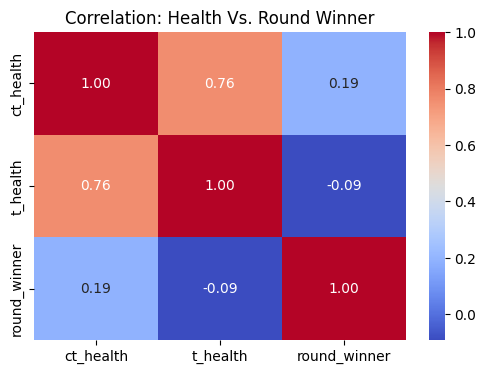

In [ ]:
health_corr = train_data[["ct_health","t_health","round_winner"]].corr()

plt.figure(figsize=(6,4))

sns.heatmap(health_corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation: Health Vs. Round Winner", fontsize=12)
plt.show()

We can see that we have a strong correlation (0.76) between the ct_health column and the t_health column, which says there are dependent in one another, and we should consider trying to merge them into one column. In other words, when one team's health is high the other team health most of the times will be high as well (make sense, the snapshot are taken in different times of the round).
But, we can also see small to non existent correlation between the ct_health/t_health columns to the round winner column, which means the "raw" features might not help us predict well the result.

**How could we solve this problem?**  
Using feature engineering of course :)  
Because the round winner is dependent on both team performance, we can find the delta (difference) between both teams and turn it into one feature instead of two, in order to create predictive feature to the target column. Let's try to do so and see wether our correlation is getting better or worse:

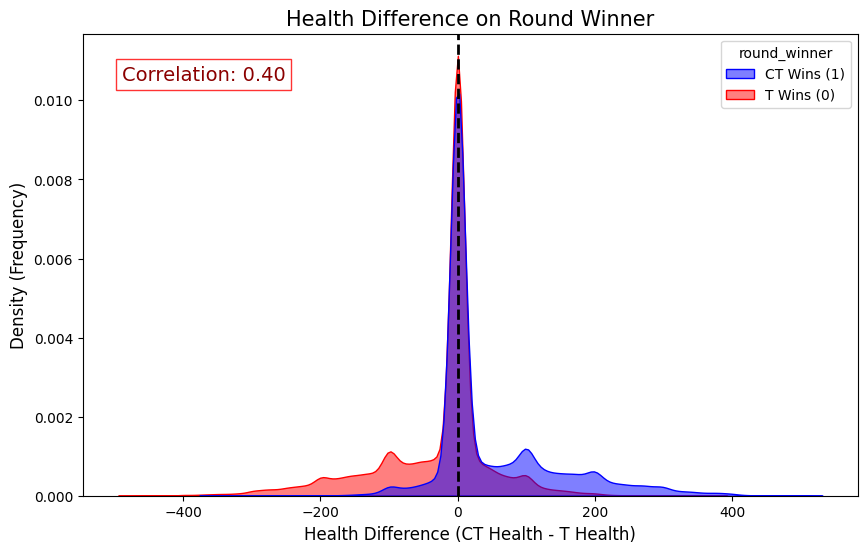

In [ ]:
health_diff = train_data['ct_health'] - train_data['t_health']

correlation_value = health_diff.corr(train_data['round_winner'])

winner_labels = train_data["round_winner"].map({0: "T Wins (0)", 1: "CT Wins (1)"})

plt.figure(figsize=(10, 6))

ax = sns.kdeplot(x=health_diff, hue=winner_labels,
            fill=True, palette={"T Wins (0)": "red", "CT Wins (1)": "blue"}, alpha=0.5)

plt.axvline(x=0, color='black', linestyle='--', linewidth=2)

plt.text(
    x=0.05,
    y=0.9,
    s=f'Correlation: {correlation_value:.2f}',
    transform=ax.transAxes, # change the absolute values into percentages to place the correlation text relative to the grid
    fontsize=14,
    color='darkred',
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='red')
)

plt.title("Health Difference on Round Winner", fontsize=15)
plt.xlabel("Health Difference (CT Health - T Health)", fontsize=12)
plt.ylabel("Density (Frequency)", fontsize=12)

plt.show()

We can see that there is a clear correlation between the difference column and between the target column (0.4).
However, we still see a massive jump in the 0 difference range. This probably represents a situation where both teams haven't encounter one another yet.
We'll try and remove these rows for the visualization to be able to see the plot more clearly and check wether the correlation value changes:

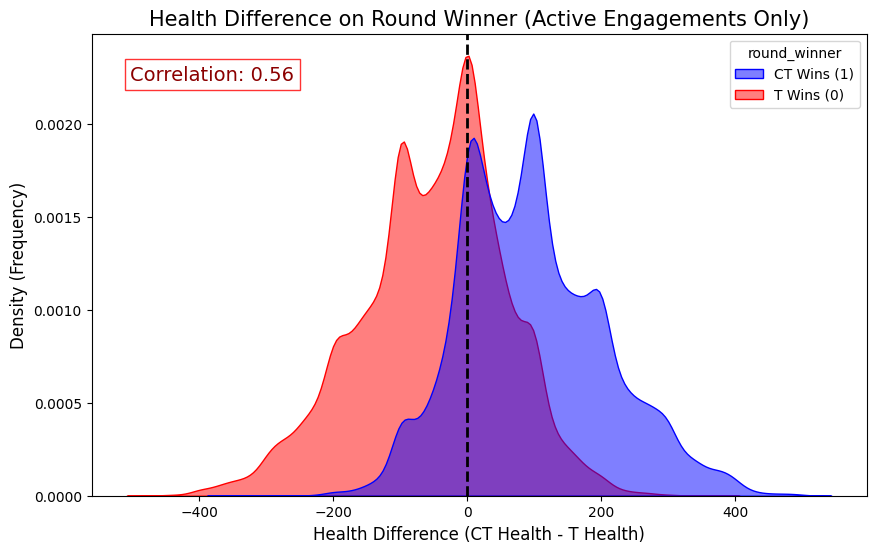

In [ ]:
active_engagements = train_data[~((train_data['ct_health'] == 500) & (train_data['t_health'] == 500))]

health_diff_active = active_engagements['ct_health'] - active_engagements['t_health']
correlation_value_active = health_diff_active.corr(active_engagements['round_winner'])

winner_labels_active = active_engagements["round_winner"].map({0: "T Wins (0)", 1: "CT Wins (1)"})

plt.figure(figsize=(10, 6))

ax = sns.kdeplot(x=health_diff_active, hue=winner_labels_active,
            fill=True, palette={"T Wins (0)": "red", "CT Wins (1)": "blue"}, alpha=0.5)

plt.axvline(x=0, color='black', linestyle='--', linewidth=2)

plt.text(
    x=0.05,
    y=0.9,
    s=f'Correlation: {correlation_value_active:.2f}',
    transform=ax.transAxes,
    fontsize=14,
    color='darkred',
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='red')
)

plt.title("Health Difference on Round Winner (Active Engagements Only)", fontsize=15)
plt.xlabel("Health Difference (CT Health - T Health)", fontsize=12)
plt.ylabel("Density (Frequency)", fontsize=12)

plt.show()

**Our hypothesis was true!**   
we see that the massive jump we had in the zero difference range reduced, the plot became clearer and the correlation value increased.  
This is the prove that the difference between both team health can help us find the identity of the winning team.

But wait! we have another two column that can be related to the health value of each team - the armor value of each team ("ct_armor" and "t_armor"). We should understand the domain to be able to make an informed decision if we should incorporate those features as well as part of the "total health" of each team.  
LLM will be useful at this stage:

**Prompt:** *" i want to see if i should incorporate the ct_armor and the t_armor columns as well as part of the "total health" for each team. How does the armor implemented in the game of cs-go? does the players start with 100 health and 100 armor? does the armor decrease first and then the health decreases after the players have 0 armor or does it happen differently?"*

**Answer:** *🛡️ Domain Knowledge: Why we shouldn't combine Health and Armor? common mistake in Feature Engineering is summing up columns that seem related without understanding the game mechanics. It might be tempting to create a total_health = health + armor feature, but here is why we shouldn't:*  
*- Starting Stats: Players spawn with 100 Health, but 0 Armor. Armor must be purchased, making the armor columns strong indicators of a team's economy, not just survivability.*  
*- Damage Mechanics: Armor does not act as a shield that depletes before health. When a player is shot, Health and Armor decrease simultaneously. Armor acts as a damage mitigator (reducing the health lost per bullet) and prevents "aim punch" (screen shaking).*  
*- The Math Doesn't Align: 1 point of Health $\neq$ 1 point of Armor. A player with 10 HP and 100 Armor will die from a single bullet, whereas a player with 100 HP and 10 Armor can survive multiple shots.*  
*Conclusion: Adding them together confuses the model. It is much better to keep them separate, or create an armor_diff feature (ct_armor - t_armor) to measure which team has the economic and tactical advantage!*

**i.e, we shouldn't merge the armor features with the health feature but we should consider create an "armor_diff" column as part of the feature engineering step.**



We'll continue the exploration for this column and explore the following anomaly we observed by looking at the graph:  

*"Clear difference between the number of times the t_health is at 0 and the ct_health is at 0. Situation where the t_health is at 0 is much more common than situation where the ct_health is at 0. This is an anomaly in relation to the rest of the data".*

**Why do you think it may happen?**  
After looking further into this anomaly, Iv'e found two main reasons for it to happen:  
1. The CT team using "save" strategy - Once the CT team realizes that they have slim chances of winning the round, they prefer to save their weapons and their ammo and wait till the bomb goes off, and the T team will win this round. This way, they do not need to buy more weapons in the next round and spend their money carefully (considering the game consists of many rounds).
2. Rules of finishing each round - When the entire CT team is dead, the round is over at the same moment. However, if the Terrorists have planted the bomb and then, all the CT team kills the entire T team, the game is not over until the CT team neutralizes the bomb, which takes more time and more snapshots are being made. This is might be another reason that's more common to see 0 health in the T team but not so common to see 0 health in the CT team.

In order to check our hypothesis, we'll need to see if the CT team actually has much higher average health when they loses in relation to the average health the terrorists have when they lose:

In [ ]:
ct_health_when_losing = train_data[train_data['round_winner'] == 0]['ct_health'].mean()

t_health_when_losing = train_data[train_data['round_winner'] == 1]['t_health'].mean()

print(f"Average CT Health when losing: {ct_health_when_losing:.1f}")
print(f"Average T Health when losing: {t_health_when_losing:.1f}")

Average CT Health when losing: 387.4
Average T Health when losing: 389.5


We see that the difference is almost 0. Does that mean our hypothesis was wrong?  
**Not really...**  
We haven't consider the masive ammount of observations that was taken before the first encounter of both teams (Where both teams' health was 500). Also, the CT team won't decide to use the "save" strategy while there is still a lot of time for the round and most of the team members are alive (can also lead to distortion in the data). We need to try and isolate the chances of survival to be able to discover if the CT team actually uses this strategy.  
Let's take to consideration what we've just said and change the filter for this calculation:

In [ ]:
ct_severe_disadvantage = train_data[
    (train_data['round_winner'] == 0) &
    (train_data['t_health'] - train_data['ct_health'] >= 200)
]

t_severe_disadvantage = train_data[
    (train_data['round_winner'] == 1) &
    (train_data['ct_health'] - train_data['t_health'] >= 200)
]

print(f"CT average health when severely outnumbered and losing: {ct_severe_disadvantage['ct_health'].mean():.1f}")
print(f"CT number of observation being outnumbered and losing: {ct_severe_disadvantage['ct_health'].count()}\n")
print(f"T average health when severely outnumbered and losing:  {t_severe_disadvantage['t_health'].mean():.1f}")
print(f"T number of observation being outnumbered and losing: {t_severe_disadvantage['t_health'].count()}")

CT average health when severely outnumbered and losing: 131.5
CT number of observation being outnumbered and losing: 2743

T average health when severely outnumbered and losing:  126.7
T number of observation being outnumbered and losing: 4413


We still didn't get the result we wanted to get, and the difference hasn't changed much, although we took only extreme cases. This gives us an indication that our first hypothesis might not be the one that causes this effect and both teams may use this strategy.
This teaches us an important lesson in Data Science, told by Nobel laureate, British economist Ronald Coase:

<center><img src="https://preview.redd.it/if-you-torture-the-data-long-enough-it-will-confess-to-v0-ikdymainj6p21.jpg?width=1080&crop=smart&auto=webp&s=16ba7998eed37c2587f4c17f80a79dff5b379610" width="800" height="400"></center>

Let's try and check our second hypothesis. We'll check the percentage of snapshots where all the terrorists were dead (t_health=0) while the bomb was already planted out of the total number of observations that all the terrorists were dead (t_health=0).  
If the percentage is high, we'll understand that many of the times that there is positive health value for the Terrorists team is also becuase they CT team hasn't neutralized the bomb.

In [ ]:
total_t_dead = len(train_data[train_data['t_health'] == 0])

t_dead_and_bomb_planted = len(train_data[(train_data['t_health'] == 0) & (train_data['bomb_planted'] == True)])

percentage = (t_dead_and_bomb_planted / total_t_dead) * 100

print(f"Total snapshots with T Health = 0: {total_t_dead}")
print(f"Snapshots where T Health = 0 AND Bomb is planted: {t_dead_and_bomb_planted}")
print(f"Percentage: {percentage:.1f}%")

Total snapshots with T Health = 0: 937
Snapshots where T Health = 0 AND Bomb is planted: 936
Percentage: 99.9%


We can see that in almost all of the time the bomb has been planted, which strengthes our hypothesis about the snapshots taken during the bomb neutralization. This is make sense because the snapshot is taken each 20 seconds and the chances of the snapshot taken exactly where the entire team has been killed and the game is over are slim to none. In order to make sure, let's try to check the number of observation where the "ct_health" column is equal to 0.   
if we'll get a small number of observation, it means that the difference is indeed coming from our hypothesis:

In [ ]:
print(f"Total snapshots with CT Health = 0: {len(train_data[train_data['ct_health']==0])}")

Total snapshots with CT Health = 0: 1


<center><img src="https://www.geo.tv/assets/uploads/updates/2022-09-03/437856_4768210_updates.jpg" width="600" height="300"></center>

**We got a definitive proof about our hypothesis!** the difference comes from the way each round might end, just as we thought.

**So why in the histogram it looked like there are close to 100 snapshots where the ct_health=0?**  
This comes from the way histogram and binning work. Because we have many possible values, python distribute each group of similar value into the same bin and shows the total number of snapshots in this bin as the y value of this bin. Doing so, we got a larger number than what we got while checking specifically the number of observations where the "ct_health"=0.

Let's try to look at one more feature, the map feature (only categorical column we have left in the entire dataset). we'll first see how does this feature bar chart looks:

/tmp/ipykernel_12642/3916290699.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_data, x=train_data["map"], palette="Set2")


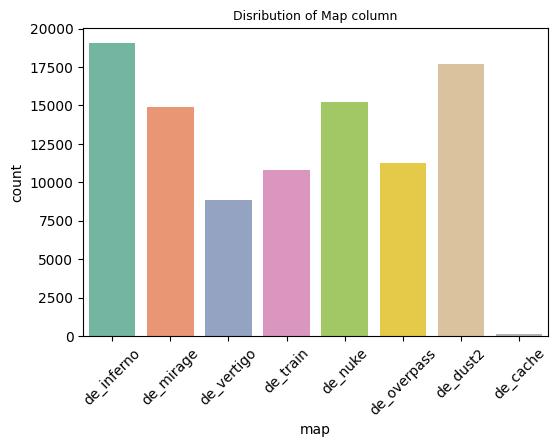

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=train_data, x=train_data["map"], palette="Set2")
plt.title("Disribution of Map column")
plt.xticks(rotation=45)
plt.show();

another tabular way to look at the data will be using the value_counts function:

In [ ]:
train_data["map"].value_counts()

,count
map,
de_inferno,19075
de_dust2,17680
de_nuke,15239
de_mirage,14890
de_overpass,11285
de_train,10786
de_vertigo,8860
de_cache,113


From first look, we can see that we have a 8 different maps, which 7 of them are being played regulary while certain map (de_cache) is rarely being played.   
Let's check why this is the case (Anomaly). We could use LLM to do so:

**Prompt:** *why does "de_cache" map almost not appear in the dataset (113 observations) while the map with the second least observations is
de_vertigo" map with 8,860 observations?"*

**Response:** *"🗺️ Domain Knowledge: The Mystery of de_cache*
*Why does the de_cache map have only 113 observations, while the next lowest (de_vertigo) has over 8,800?*

*Using a quick domain check (or asking an LLM!), we discover a historical game event: In March 2019, the developers removed de_cache from the official competitive "Active Duty Map Pool" for a visual rework and replaced it with de_vertigo. Since our dataset is based on professional tournaments from 2019-2020, de_cache was simply not played. Those 113 snapshots likely belong to a single unofficial showmatch!"*

usually, in this situation when we have a category that is redundant and may introduce noise to our model we should remove all rows with this category in order to turn our model to be more robust and prevent overfitting.

In [ ]:
train_data = train_data[train_data["map"] != "de_cache"]

But wait! what if our test_data have observations that were played on the "de_cache" map as well?  
Let's check:

In [ ]:
test_data["map"].value_counts()

,count
map,
de_inferno,4736
de_dust2,4464
de_nuke,3786
de_mirage,3686
de_overpass,2796
de_train,2705
de_vertigo,2277
de_cache,32


Unfortunately, we see that we also have this map in our test_data. Usually, if we were sure we won't stumble upon this map in the future (which is relevant in this case because we checked and saw that the map has been removed, so future competitions won't be using this map at all), we'll remove the relevant rows from the train set as well as the test set (Simple solution).

**But what if we're not sure if we'll stumble upon new categories in the future or in the test set (The model wouldn't know what to do with them)?**  

For this option, we can use the "OneHotEncoder(handle_unknown="ignore")" command.  
The OneHotEncoder command is usually used to handle categorical data by converting each category into a new binary column (0 or 1). By adding the handle_unknown="ignore" parameter, we are building a robust Machine Learning pipeline.

If the model encounters a category in the test set (or in a real-world production environment) that it never saw during training (like our dropped de_cache), instead of crashing and throwing an error, it simply ignores it. It assigns a value of 0 to all the map-related columns for that specific snapshot.

Essentially, the model says: "I don't recognize this map, so I will give it zero weight and make my prediction based purely on the other features (like health, money, and weapons). We'll use this command before building our prediction models. We should note that the One Hot Encoding method is mostly good for categorical feature with small number of categories.

This is because this method increasing the number of columns in the dataset and might cause overfitting by memorizing the training data set.

Let's dive deeper into the "map" feature and check wether the map might affect the winning team. in order to do so, we'll check the number of times each team won the round with respect to each map:

In [ ]:
# Create a pivot table using 'count'
# We specify 'time_left' as the values column just so pandas has a column of non-null values to count.
map_wins = train_data.pivot_table(index='map',
                                  columns='round_winner',
                                  values='time_left',
                                  aggfunc='count',
                                  fill_value=0)

# Rename the columns for clarity (assuming 0 = T win, 1 = CT win)
map_wins.columns = ['T Wins', 'CT Wins']

# 2. Calculate the win percentages for each map
total_wins = map_wins['T Wins'] + map_wins['CT Wins']
map_win_pct = map_wins.div(total_wins, axis=0) * 100
map_win_pct.columns = ['T Win %', 'CT Win %']

# 3. Calculate the difference (CT Win % - T Win %)
map_win_pct['CT - T Win % Diff'] = map_win_pct['CT Win %'] - map_win_pct['T Win %']

# 4. Combine both dataframes into one comprehensive table
map_analysis = pd.concat([map_wins, map_win_pct.round(1)], axis=1)

# 5. Sort by the difference in descending order (Most CT-sided to most T-sided)
map_analysis = map_analysis.sort_values(by='CT - T Win % Diff', ascending=False)

# Display the table
map_analysis

,T Wins,CT Wins,T Win %,CT Win %,CT - T Win % Diff
map,,,,,
de_train,4935,5851,45.8,54.2,8.5
de_nuke,7066,8173,46.4,53.6,7.3
de_overpass,5651,5634,50.1,49.9,-0.2
de_mirage,7509,7381,50.4,49.6,-0.9
de_vertigo,4677,4183,52.8,47.2,-5.6
de_dust2,9585,8095,54.2,45.8,-8.4
de_inferno,10472,8603,54.9,45.1,-9.8


We can also show the results using graph:

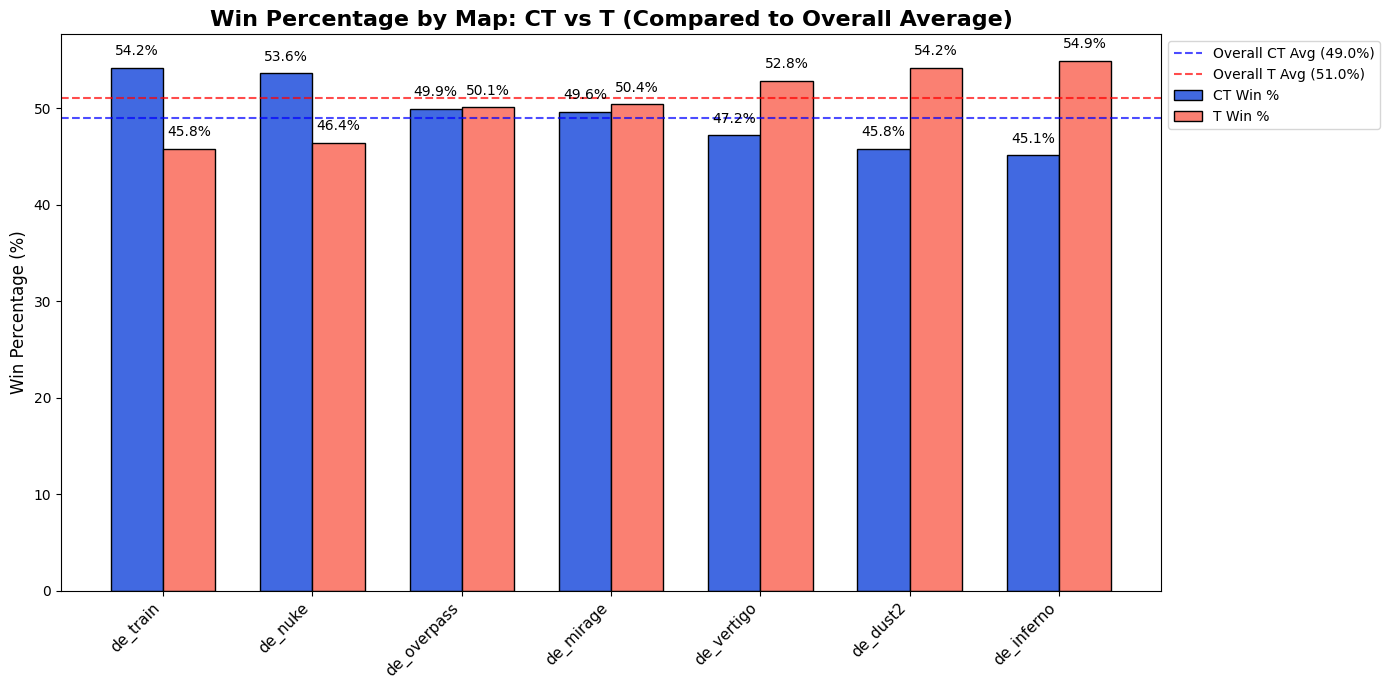

In [ ]:
# 1. Calculate the overall average win percentage across the entire dataset
total_t_wins_overall = map_wins['T Wins'].sum()
total_ct_wins_overall = map_wins['CT Wins'].sum()
total_rounds = total_t_wins_overall + total_ct_wins_overall

overall_ct_win_pct = (total_ct_wins_overall / total_rounds) * 100
overall_t_win_pct = (total_t_wins_overall / total_rounds) * 100

# 2. Set up the figure and axes
fig, ax = plt.subplots(figsize=(14, 7))
maps = map_analysis.index
x = np.arange(len(maps))  # the label locations
width = 0.35  # the width of the bars

# 3. Plot the bars (CT in blue, T in red)
rects1 = ax.bar(x - width/2, map_analysis['CT Win %'], width, label='CT Win %', color='royalblue', edgecolor='black')
rects2 = ax.bar(x + width/2, map_analysis['T Win %'], width, label='T Win %', color='salmon', edgecolor='black')

# 4. Add the overall averages as dashed reference lines
ax.axhline(y=overall_ct_win_pct, color='blue', linestyle='--', alpha=0.7,
           label=f'Overall CT Avg ({overall_ct_win_pct:.1f}%)')
ax.axhline(y=overall_t_win_pct, color='red', linestyle='--', alpha=0.7,
           label=f'Overall T Avg ({overall_t_win_pct:.1f}%)')

# 5. Format the graph (titles, axes, and legend)
ax.set_ylabel('Win Percentage (%)', fontsize=12)
ax.set_title('Win Percentage by Map: CT vs T (Compared to Overall Average)', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(maps, rotation=45, ha='right', fontsize=11)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1)) # Place legend outside the plot so it doesn't hide data

# 6. Add text labels (percentages) on top of each bar for readability
for bar in rects1:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', va='bottom', fontsize=10)

for bar in rects2:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', va='bottom', fontsize=10)

# Automatically adjust layout so text doesn't get cut off
plt.tight_layout()
plt.show()

We can see that in 2 maps ("de_train" and "de_nuke"), there is a clear advantage to the CT team, while on 3 other maps ("de_vertigo", "de_dust2", and "de_inferno"), there is a clear advantage to the T team. In the remaining 2 maps ("de_overpass" and "de_mirage"), there is no clear advantage for one team over the other.

Why is this happening? Can we utilize the LLM in order to analyze each of the maps and find the dominant features of each map, and compare them?
This might help us quantify this categorical column and add more features that will help with the prediction.

Since we don't have much time, we'll keep this as an idea :)

Let's try and focus on filling the missing values in our dataset. If you remember, we saw that the data has 41 missing values in the "ct_helmets" column. How should we fill those values? Any ideas?

<center><img src="https://media.makeameme.org/created/one-does-not-a4d8d8add9.jpg" width="600" height="400"></center>

Because there are only 41 missing values in a dataset of almost 98,000 rows, we can decide to delete those rows from the dataset, and it won't matter.
However, what if we've had much more than 41 missing values? We don't want to delete all the rows that have missing values because we might lose a lot of data...  
Here are a few methods we can use to fill those values (from simplest to most complicated):

1.Fill the missing values using the mean / median value of the column:
This is a common method while there is relatively small amount of missing values and we don't want to waste a lot of time filling those missing values.
  
**When should we fill the values using mean and when should we fill the values using median?**  
The answer depends on the column we deal with and it's distribution.
- Median (For Skewed Data & Outliers): We use the median when our data has extreme outliers or an asymmetrical distribution (a long tail). The median is "robust" to outliers, meaning it doesn't get dragged by extreme values.

  Classic Example - Salaries: Imagine 9 people in a room earn 50,000 USD a year, and 1 person (a billionaire) earns 10,000,000 USD. The mean salary in this room is over 1,000,000 USD! If we fill a missing value with the mean, we are assigning a millionaire's salary to an average person. The median, however, will be exactly 50,000 USD, which perfectly represents the "typical" person in the room.  

- Mean (For Symmetrical/Normal Data): We use the mean when our data is roughly symmetrical (like a bell curve) and lacks crazy outliers. Because the mean incorporates every single value in its calculation, it represents the absolute mathematical center of balanced data.

  Classic Example - Heights: If we are looking at the heights of adult men, most people cluster around 1.75m to 1.80m, with very few extremes. There are no 10-meter-tall humans to skew the data. In this case, filling a missing value with the average height is highly accurate and mathematically sound.

Mean value of the "ct_hemlets" column is: 2.0544623314991717
Median value of the "ct_hemlets" column is: 2.0


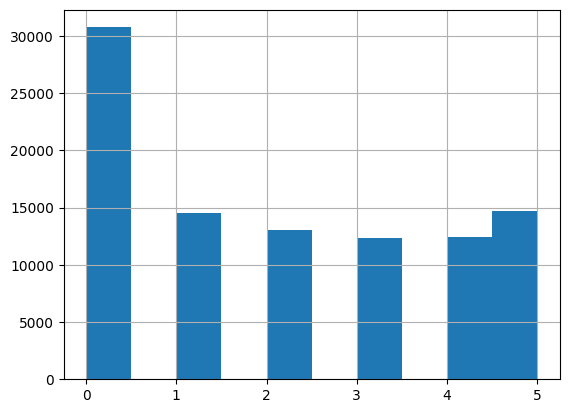

In [ ]:
print(f'Mean value of the "ct_hemlets" column is: {train_data["ct_helmets"].mean()}')
print(f'Median value of the "ct_hemlets" column is: {train_data["ct_helmets"].median()}')
train_data["ct_helmets"].hist();

We could choose to fill all missing values with 2 (important to fill with an integer to keep the column type as integer) using the following code:

```python
train_data["ct_health"] = train_data["ct_health"].fillna(2).astype(int)

2."Conditional Imputation" - If we want to be more precise than just using a global constant like mean or median, we can fill missing values based on correlations with other columns. We'll assume that the number of helmets each team has is correlated with the amount of money each team has ("ct_money"). Using this assumption, instead of one average for everyone, we calculate two different medians:
- "Rich Team Median": For teams with above-average money
- "Poor Team Median": For teams with below-average money

This way, if a snapshot is missing the helmet count, but we see the team is rich, we fill it with a higher, more realistic value.  
Let's check if our assumtion is correct:

In [ ]:
correlation = train_data['ct_money'].corr(train_data['ct_helmets'])
print(f"Correlation between Money and Helmets: {correlation:.2f}")

Correlation between Money and Helmets: 0.25


We see that the correlation value in low. Instead of the "ct_money" column, let's see what other columns has strong correlation with the "ct_helmets" column:

In [ ]:
# Select only numerical columns (integers and floats)
numerical_data = train_data.select_dtypes(include=['number'])

# Now calculate the correlation matrix
correlations = numerical_data.corr()

# Let's look specifically at how columns correlate with 'ct_helmets'
helmet_correlations = correlations['ct_helmets'].sort_values(ascending=False)

print("Top 10 correlations with helmets:")
print(helmet_correlations.head(10))

Top 10 correlations with helmets:
ct_helmets                      1.000000
ct_defuse_kits                  0.767434
ct_grenade_flashbang            0.728538
ct_armor                        0.695009
ct_grenade_smokegrenade         0.639235
ct_grenade_incendiarygrenade    0.600317
ct_grenade_hegrenade            0.569993
ct_weapon_m4a4                  0.456410
ct_weapon_awp                   0.417202
ct_weapon_ak47                  0.340588
Name: ct_helmets, dtype: float64


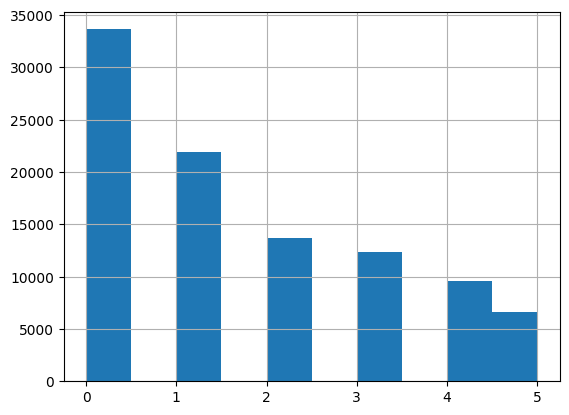

In [ ]:
train_data["ct_defuse_kits"].hist();

We see that the "ct_defuse_kits" act similarly to the "ct_helmets" column. We'll use the same logic presented in section 2 but instead of the money column will use the defuse kits column as an helper:

In [ ]:
# 1. Calculate the overall defuse kits mean to define the threshold
kits_mean = train_data['ct_defuse_kits'].mean()

# 2. Calculate separate medians for high kits and low kits scenarios
high_kits_helmet_median = train_data[train_data['ct_defuse_kits'] >= kits_mean]['ct_helmets'].median()
low_kits_helmet_median = train_data[train_data['ct_defuse_kits'] < kits_mean]['ct_helmets'].median()

# Let's print the medians to see the difference!
print(f"Median helmets (High Kits): {high_kits_helmet_median}")
print(f"Median helmets (Low Kits): {low_kits_helmet_median}")

# 3. Apply the conditional fill
# Fill missing helmets for teams with high amount of kits
train_data.loc[train_data['ct_defuse_kits'] >= kits_mean, 'ct_helmets'] = \
    train_data.loc[train_data['ct_defuse_kits'] >= kits_mean, 'ct_helmets'].fillna(high_kits_helmet_median)

# Fill missing helmets for teams with low amount of kits
train_data.loc[train_data['ct_defuse_kits'] < kits_mean, 'ct_helmets'] = \
    train_data.loc[train_data['ct_defuse_kits'] < kits_mean, 'ct_helmets'].fillna(low_kits_helmet_median)

# 4. Final touch: Ensure the column is an integer
train_data['ct_helmets'] = train_data['ct_helmets'].astype(int)

Median helmets (High Kits): 4.0
Median helmets (Low Kits): 0.0


3.Algorithmic Imputation (KNN) - We can use machine learning algorithms to clean our data for machine learning purposes.
Instead of relying on just one column (like defuse kits), we can look at the entire "tactical picture" of the snapshot.  
Using K-Nearest Neighboors, the algorithm looks at a row with missing helmets, searches the dataset for the 5 rounds that are most similar to it (based on the columns we'll choose), and borrows their helmet count.  

Because KNN algorithm is distance based and also very sensitive to "the curse of dimensionality" we should be strict about the number of columns we choose and the normalization of the data.  

- We'll choose all the features with correlation values over 0.6 based on the results we've got earlier. Adding more features might lead to overfitting.
- In terms of choosing the K hyperparamater, we'll choose K=5. In many times, K=5 is the industry standard value (Tradeoff between overfitting and underfitting). Also, K=5 is an odd number, which helps with situations of "tie-breaking" conflicts. If we want to be extra careful, we could also use cross-validation and Elbow Curve to see exactly which K minimzes the error of our model.
- In terms of Scaling our data before performing the KNN imputation, we'll use Min Max Scaler. The Min Max Scaler is more suited for the data we're working with in this case (with no extreme outlier values that will distort the entire KNN Imputation.


We could use the following code to implement it:

```python
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

# 1. Select the target column + top highly correlated features (Our >0.60 threshold group):
features = ['ct_helmets', 'ct_defuse_kits', 'ct_grenade_flashbang', 'ct_armor', 'ct_grenade_smokegrenade', 'ct_grenade_incendiarygrenade']
data_for_knn = train_data[features].copy()

# 2. Normalize the data (MinMaxScaler keeps our counts proportionally between 0 and 1):
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data_for_knn)

# 3. Initialize and apply the KNN Imputer (looking at the 5 nearest neighbors as our strong baseline):
imputer = KNNImputer(n_neighbors=5)
imputed_scaled_data = imputer.fit_transform(scaled_data)

# 4. Inverse transform to get the actual helmet counts back, and round to integers:
imputed_data = scaler.inverse_transform(imputed_scaled_data)
train_data['ct_helmets_knn'] = imputed_data[:, 0].round().astype(int)

Let's continue with the feature engineering stage:

Before we'll start, **what is exactly Feature Engineering?**  

Feature Engineering is often considered the "art" of Data Science. It is the process of using domain knowledge to create new features (columns) from existing ones to help our machine learning models uncover hidden patterns.

There are many transformations we could perform on this dataset:
* **Aggregation:** We could sum up all specific grenades into a single `total_grenades` column to reduce dimensionality.
* **Log Transformations:** Applying a log transform to columns like `ct_money` to represent the economic concept of **Diminishing Marginal Utility** (the first 1,000$ you earn is tactically much more impactful than the 15,000th dollar).
* **Relative Advantage (Differences):** Creating features like `money_diff = ct_money - t_money` to explicitly feed the model the relative advantage one team has over the other.

However, since our time today is limited, we will focus on engineering **one highly impactful feature** by utilizing a Large Language Model (LLM) to enrich our dataset!

#### The LLM "Equipment Value" Feature
If we look at our data, we have dozens of columns representing specific weapons (e.g., `ct_weapon_ak47`, `t_weapon_mac10`).
This creates two major problems:
1.  **Sparsity:** Like we've already seen, these columns are mostly zeros (highly sparse), which adds a lot of noise to our model.
2.  **Lack of Context:** If you don't play CS:GO, how does the model know if an `awp` is better than a `glock`?

There is a universal rule in gaming: **Expensive equipment is generally better and more lethal.** Instead of forcing the model to figure out the value of each weapon blindly, we asked an LLM (like ChatGPT/Gemini) to generate a Python dictionary containing the official in-game prices of all CS:GO weapons. By multiplying the count of each weapon by its real price, we can aggregate all these sparse columns into two powerful numerical features: `ct_equipment_value` and `t_equipment_value`.

This single metric quantifies the exact tactical firepower of a team, allowing us to eventually drop the noisy, sparse weapon columns!

In [ ]:
# 1. Comprehensive dictionary with exact CS:GO in-game prices for discrete items (Counts)
equipment_prices = {
    # Rifles & Snipers
    'weapon_ak47': 2700, 'weapon_aug': 3300, 'weapon_awp': 4750, 'weapon_famas': 2050,
    'weapon_g3sg1': 5000, 'weapon_galilar': 2000, 'weapon_m4a1s': 3100, 'weapon_m4a4': 3100,
    'weapon_scar20': 5000, 'weapon_sg553': 3000, 'weapon_ssg08': 1700,

    # SMGs
    'weapon_bizon': 1400, 'weapon_mac10': 1050, 'weapon_mp5sd': 1500, 'weapon_mp7': 1500,
    'weapon_mp9': 1250, 'weapon_p90': 2350, 'weapon_ump45': 1200,

    # Heavy (Shotguns & Machine Guns)
    'weapon_m249': 5200, 'weapon_mag7': 1300, 'weapon_negev': 1700, 'weapon_nova': 1050,
    'weapon_sawedoff': 1100, 'weapon_xm1014': 2000,

    # Pistols
    'weapon_cz75auto': 500, 'weapon_elite': 400, 'weapon_glock': 200, 'weapon_r8revolver': 600,
    'weapon_deagle': 700, 'weapon_fiveseven': 500, 'weapon_usps': 200, 'weapon_p250': 300,
    'weapon_p2000': 200, 'weapon_tec9': 500,

    # Grenades
    'grenade_hegrenade': 300, 'grenade_flashbang': 200, 'grenade_smokegrenade': 300,
    'grenade_incendiarygrenade': 600, 'grenade_molotovgrenade': 400, 'grenade_decoygrenade': 50,

    # Gear
    'helmets': 350, 'defuse_kits': 400
}

# 2. Initialize the new features with 0
train_data['ct_equipment_value'] = 0
train_data['t_equipment_value'] = 0

# 3. Iterate through the dictionary for all discrete items
for item, price in equipment_prices.items():
    ct_col = f'ct_{item}'
    t_col = f't_{item}'

    if ct_col in train_data.columns:
        train_data['ct_equipment_value'] += train_data[ct_col] * price

    if t_col in train_data.columns:
        train_data['t_equipment_value'] += train_data[t_col] * price

# 4. Special mathematical handling for Armor (Continuous variable, max 500 points per team)
# A full Kevlar vest costs $650 and gives 100 armor points. We divide by 100 to get the "amount" of full vests.
train_data['ct_equipment_value'] += (train_data['ct_armor'] / 100) * 650
train_data['t_equipment_value'] += (train_data['t_armor'] / 100) * 650

# 5. Round the final equipment values and convert to integers
train_data['ct_equipment_value'] = train_data['ct_equipment_value'].round().astype(int)
train_data['t_equipment_value'] = train_data['t_equipment_value'].round().astype(int)

# Let's peek at our new powerful features!
train_data[['ct_money', 'ct_equipment_value', 't_money', 't_equipment_value']].head()

,ct_money,ct_equipment_value,t_money,t_equipment_value
46932,18850,23346,4700,4752
10028,300,14150,1450,19673
54116,30900,25650,21100,26330
97546,34850,28782,150,17586
2964,24400,30559,200,21400


We could also divide the value to cateogories as the LLM suggested and check which category might help us predict the winner more accurately, but we'll ignore this idea at the moment.

Let's check the correlation of the columns we've just created and check the correlation of the difference between the "ct_equipment_value" and the "t_equipment_value" to the target column as well:

In [ ]:
# 1. Create a temporary theoretical Series for the difference
equipment_value_diff = train_data['ct_equipment_value'] - train_data['t_equipment_value']

# 2. Calculate correlations with the target variable ('round_winner')
correlation_ct = train_data['ct_equipment_value'].corr(train_data['round_winner'])
correlation_t = train_data['t_equipment_value'].corr(train_data['round_winner'])
correlation_diff = equipment_value_diff.corr(train_data['round_winner'])

print("Correlation with Round Winner Column (Target column):")
print(f"CT Equipment Absolute Value:  {correlation_ct:.3f}")
print(f"T Equipment Absolute Value:   {correlation_t:.3f}")
print(f"equipment Value difference: {correlation_diff:.3f}")

Correlation with Round Winner Column (Target column):
CT Equipment Absolute Value:  0.327
T Equipment Absolute Value:   -0.288
equipment Value difference: 0.522


**This correlation value is a great indication that the total value of the gear actually effects the identity of the winner of the round!**

After seeing the correlation of the equipment value difference to the target function, we should add this column to the dataset.
We'll also add the health_diff column and the armor_diff column, as we saw in the EDA step:

In [ ]:
# 1. Create the Delta features (Positive = CT advantage, Negative = T advantage)
train_data['equipment_value_diff'] = train_data['ct_equipment_value'] - train_data['t_equipment_value']
train_data['health_diff'] = train_data['ct_health'] - train_data['t_health']
train_data['armor_diff'] = train_data['ct_armor'] - train_data['t_armor']

# 2. Let's verify our intuition by looking at their correlation with the target
delta_columns = ['equipment_value_diff', 'health_diff', 'armor_diff', 'round_winner']
correlations = train_data[delta_columns].corr()['round_winner'].drop('round_winner')

print("--- Correlation of Delta Features with Round Winner ---")
print(correlations.sort_values(ascending=False))

--- Correlation of Delta Features with Round Winner ---
armor_diff              0.527658
equipment_value_diff    0.521852
health_diff             0.398544
Name: round_winner, dtype: float64


We'll now drop the columns that are included in the cols_to_remove list weve created:

In [ ]:
train_data = train_data.drop(columns=cols_to_remove, errors="ignore")

train_data.head()

,time_left,ct_score,t_score,map,bomb_planted,ct_health,t_health,ct_armor,t_armor,ct_money,t_money,ct_helmets,t_helmets,ct_defuse_kits,ct_players_alive,t_players_alive,ct_weapon_ak47,t_weapon_ak47,ct_weapon_aug,ct_weapon_awp,t_weapon_awp,ct_weapon_cz75auto,t_weapon_glock,ct_weapon_m4a4,ct_weapon_mp9,ct_weapon_sg553,t_weapon_sg553,ct_weapon_deagle,t_weapon_deagle,ct_weapon_usps,ct_weapon_p250,t_weapon_p250,ct_weapon_p2000,ct_grenade_hegrenade,t_grenade_hegrenade,ct_grenade_flashbang,t_grenade_flashbang,ct_grenade_smokegrenade,t_grenade_smokegrenade,ct_grenade_incendiarygrenade,t_grenade_incendiarygrenade,ct_grenade_molotovgrenade,t_grenade_molotovgrenade,ct_grenade_decoygrenade,t_grenade_decoygrenade,round_winner,ct_equipment_value,t_equipment_value,equipment_value_diff,health_diff,armor_diff
46932,33.46,13,15,de_inferno,1,338,80,384,85,18850,4700,4,0,4,4,2,0,0,0,1,0,1,0,1,0,2,1,1,1,1,1,0,0,1,0,1,0,2,0,2,0,0,0,0,0,1,23346,4752,18594,258,299
10028,51.48,15,7,de_mirage,0,300,212,300,342,300,1450,2,4,1,3,4,0,3,1,0,1,0,3,2,0,0,0,0,0,3,0,0,0,0,0,2,4,0,1,1,1,0,1,0,0,0,14150,19673,-5523,88,-42
54116,94.90,17,15,de_vertigo,0,381,495,400,497,30900,21100,4,5,4,4,5,0,1,0,1,1,0,2,3,0,0,3,1,1,0,3,2,0,2,1,4,4,4,3,3,0,0,3,0,0,0,25650,26330,-680,-114,-97
97546,99.70,4,5,de_inferno,0,500,274,451,367,34850,150,4,4,4,5,4,1,4,0,1,0,0,4,2,0,1,0,1,0,4,0,0,0,2,1,4,1,5,3,3,0,0,2,0,0,1,28782,17586,11196,226,84
2964,94.89,11,12,de_train,0,500,500,486,500,24400,200,5,5,5,5,5,0,4,0,1,0,0,5,3,0,1,1,2,0,1,2,0,0,2,0,4,2,4,4,3,0,0,0,0,0,1,30559,21400,9159,0,-14


Becuase a lot of the models can't work with categorical columns (and because we've decided to remove "de_cache" map while still having this category under the map column in the test_data), we'll use the One Hot Encoding method, which converting each category into a new binary column (0 or 1).   
What happens if our model encounters a new map in the test set (or in the real world) that it never saw during training?  
If we don't plan for this, the code will crash. By using `OneHotEncoder(handle_unknown="ignore")`, we tell the model:  

*"If you see a map you don't recognize, just assign 0 to all known map columns and make your prediction based purely on the other tactical features (money, health, weapons)."*

**What could be the main problem of the One Hot Encoding method?**

In [ ]:
# 1. Initialize the OneHotEncoder
# sparse_output=False ensures we get a normal array back, not a sparse matrix
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# 2. Fit the encoder on the 'map' column and transform it
map_encoded_array = encoder.fit_transform(train_data[['map']])

# 3. Get the new column names (e.g., 'map_de_dust2', 'map_de_mirage')
new_map_columns = encoder.get_feature_names_out(['map'])

# 4. Create a new DataFrame with the encoded columns
map_encoded_df = pd.DataFrame(map_encoded_array, columns=new_map_columns, index=train_data.index)

# 5. Concatenate the new columns to our original dataset and drop the old text column
train_data = pd.concat([train_data, map_encoded_df], axis=1)
train_data = train_data.drop(columns=['map'])

print(f"New shape of our dataset: {train_data.shape}")
train_data[new_map_columns].head()

New shape of our dataset: (97815, 57)


,map_de_dust2,map_de_inferno,map_de_mirage,map_de_nuke,map_de_overpass,map_de_train,map_de_vertigo
46932,0.0,1.0,0.0,0.0,0.0,0.0,0.0
10028,0.0,0.0,1.0,0.0,0.0,0.0,0.0
54116,0.0,0.0,0.0,0.0,0.0,0.0,1.0
97546,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2964,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
train_data.describe()

,time_left,ct_score,t_score,bomb_planted,ct_health,t_health,ct_armor,t_armor,ct_money,t_money,ct_helmets,t_helmets,ct_defuse_kits,ct_players_alive,t_players_alive,ct_weapon_ak47,t_weapon_ak47,ct_weapon_aug,ct_weapon_awp,t_weapon_awp,ct_weapon_cz75auto,t_weapon_glock,ct_weapon_m4a4,ct_weapon_mp9,ct_weapon_sg553,t_weapon_sg553,ct_weapon_deagle,t_weapon_deagle,ct_weapon_usps,ct_weapon_p250,t_weapon_p250,ct_weapon_p2000,ct_grenade_hegrenade,t_grenade_hegrenade,ct_grenade_flashbang,t_grenade_flashbang,ct_grenade_smokegrenade,t_grenade_smokegrenade,ct_grenade_incendiarygrenade,t_grenade_incendiarygrenade,ct_grenade_molotovgrenade,t_grenade_molotovgrenade,ct_grenade_decoygrenade,t_grenade_decoygrenade,round_winner,ct_equipment_value,t_equipment_value,equipment_value_diff,health_diff,armor_diff,map_de_dust2,map_de_inferno,map_de_mirage,map_de_nuke,map_de_overpass,map_de_train,map_de_vertigo
count,97815.000000,97815.000000,97815.000000,97815.000000,97815.000000,97815.000000,97815.000000,97815.000000,97815.000000,97815.000000,97815.000000,97815.000000,97815.00000,97815.000000,97815.000000,97815.000000,97815.000000,97815.000000,97815.000000,97815.000000,97815.000000,97815.000000,97815.000000,97815.000000,97815.000000,97815.000000,97815.000000,97815.000000,97815.000000,97815.000000,97815.000000,97815.000000,97815.000000,97815.000000,97815.000000,97815.000000,97815.000000,97815.000000,97815.000000,97815.000000,97815.000000,97815.000000,97815.000000,97815.000000,97815.000000,97815.000000,97815.000000,97815.000000,97815.000000,97815.000000,97815.000000,97815.000000,97815.000000,97815.000000,97815.000000,97815.000000,97815.000000
mean,97.864188,6.704360,6.781659,0.111813,412.080386,402.621449,314.127148,298.508112,9784.834126,11243.454992,2.053683,2.775137,1.61375,4.274212,4.265787,0.274580,1.244625,0.132791,0.573245,0.321075,0.151787,3.304585,1.077279,0.147902,0.239953,0.824393,0.441384,0.383939,3.179615,0.237131,0.292419,0.173542,0.900036,0.439135,1.851025,1.859408,1.540459,1.628953,1.001902,0.019803,0.047968,1.351500,0.028135,0.025599,0.489904,15082.433635,13571.847201,1510.586434,9.458938,15.619036,0.180749,0.195011,0.152226,0.155794,0.115371,0.110269,0.090579
std,54.452454,4.788124,4.824456,0.315138,132.307549,140.002881,170.953520,174.513694,11216.423548,12150.904558,1.841983,2.010150,1.60562,1.204944,1.229174,0.584956,1.363348,0.456169,0.673153,0.476966,0.445388,1.626925,1.217611,0.475108,0.554962,1.139460,0.834481,0.817365,1.586833,0.534464,0.580531,0.424320,1.283789,0.809480,1.771269,1.793887,1.738560,1.829335,1.458744,0.143302,0.227690,1.662654,0.170832,0.163472,0.499901,10189.547252,9051.771732,11368.978383,95.206109,205.361822,0.384812,0.396211,0.359242,0.362662,0.319471,0.313227,0.287011
min,0.030000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-31850.000000,-466.000000,-500.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,54.920000,3.000000,3.000000,0.000000,350.000000,322.000000,194.000000,174.000000,1300.000000,1600.000000,0.000000,0.000000,0.00000,4.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4726.000000,3950.000000,-5315.000000,0.000000,-96.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,94.910000,6.000000,6.000000,0.000000,500.000000,500.000000,377.000000,334.000000,5500.000000,7150.000000,2.000000,3.000000,1.00000,5.000000,5.000000,0.000000,1.000000,0.000000,0.000000,0.00000

Before Starting building models, We'll also need to use Feature Scaling.
When looking at our data, we see that some columns (like the t_money and ct_money columns) has extreme values and are very right skewed in comparison to other columns. If we'll use Min Max Scaler, these kind of columns will become redundant becuase of their distribution.  

**What is a possible solution for this problem?**

**Log Transformation + Min-Max Scaling**
Money values follow an **exponential** distribution. Tactically, the jump from 0 USD to 4,000 USD is game-changing, but the jump from 76,000 USD to 80,000 USD means almost nothing (Diminishing Marginal Utility).

By applying a Logarithmic transformation to our heavy economic features, we naturally compress the extreme outliers while preserving the critical differences at the lower end. After the log transform, we can safely apply `MinMaxScaler` to the entire dataset!

In [ ]:
# 1. Separate Features (X) and Target (y)
X_train = train_data.drop(columns=['round_winner'])
y_train = train_data['round_winner']

# 2. Apply Log Transformation to the highly skewed "t_money" and "ct_money" features
# We use log1p (which calculates log(1 + x)) because log(0) is undefined.
skewed_features = ['ct_money', 't_money']

for col in skewed_features:
    X_train[col] = np.log1p(X_train[col])

# 3. Initialize and apply the Min-Max Scaler
scaler = MinMaxScaler()
X_train_scaled_array = scaler.fit_transform(X_train)

# 4. Convert back to DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled_array, columns=X_train.columns, index=X_train.index)

# Let's see the transformed result!
X_train_scaled[['ct_money', 't_money']].head()

,ct_money,t_money
46932,0.871966,0.748953
10028,0.505511,0.644831
54116,0.915742,0.881954
97546,0.926397,0.444408
2964,0.894824,0.469743


Now that our data is fully numeric, scaled, and clean, we are ready for Machine Learning!

Before we train any models, we need a fair way to evaluate them. We will **NOT** touch our Test Set (`X_test`). Instead, we will split our scaled training data into a `sub_train` set and a `validation` set.

For our models, we will use **K-Fold Cross-Validation** on the `sub_train` set. This automatically splits the data into folds, trains on some, validates on others, and repeats this process to find the best hyperparameters. Finally, we will test our tuned models on the unseen `validation` set.

### 1. Baseline Model: Logistic Regression
We'll use a Logistic Regression model as our baseline. Since we have many features, we run the risk of **Overfitting** (memorizing the training data). To prevent this, we use **Regularization** (penalizing the model for having excessively large weights).

Instead of running a default model, we will use `GridSearchCV` to find the optimal regularization parameters:

* **L2 (Ridge):** Shrinks all weights:
  $$J(\theta) = \text{Loss}(\theta) + \lambda \sum_{j=1}^{p} \theta_{j}^{2}$$
* **L1 (Lasso):** Can push weights of useless features to exactly 0 (Feature Selection):
  $$J(\theta) = \text{Loss}(\theta) + \lambda \sum_{j=1}^{p} |\theta_{j}|$$
* **C Parameter:** The inverse of regularization strength. (Smaller C = Stronger penalty):
  $$C = \frac{1}{\lambda}$$

In [ ]:
# 1. Create an internal Validation Set for a FAIR comparison later
X_sub_train, X_val, y_sub_train, y_val = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=42, shuffle=True
)

# 2. Initialize the baseline model
log_reg = LogisticRegression(max_iter=200, random_state=42)

# 3. Define a focused grid of hyperparameters to test
param_grid_log = {
    'C': [0.1, 1, 10],            # Testing strong, default, and weak penalties
    'penalty': ['l1', 'l2'],      # Testing Lasso vs Ridge
    'solver': ['liblinear']       # The solver that supports both L1 and L2
}

# 4. Set up the Grid Search with 4-Fold Cross Validation
grid_search_log = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid_log,
    cv=4,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# 5. Fit the Grid Search to our SUB-TRAIN data
# Note: GridSearchCV automatically refits the best model on the entire X_sub_train at the end!
print("Starting Grid Search for Logistic Regression...")
grid_search_log.fit(X_sub_train, y_sub_train)

# Extract the best model
best_log_reg = grid_search_log.best_estimator_

print("\n--- Logistic Regression Results ---")
print(f"Best Parameters: {grid_search_log.best_params_}")
print(f"Best CV AUC (on sub-train): {grid_search_log.best_score_:.4f}")

Starting Grid Search for Logistic Regression...
Fitting 4 folds for each of 6 candidates, totalling 24 fits

--- Logistic Regression Results ---
Best Parameters: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV AUC (on sub-train): 0.8479


### 2. Advanced Model: XGBoost
Our Logistic Regression gave us a solid baseline. But CS:GO is a highly complex, non-linear game. Sometimes, having $5000 means nothing if you have 10 HP and the enemy has an AWP.

Tree-based models, particularly **XGBoost (Extreme Gradient Boosting)**, are the kings of finding these complex, non-linear relationships. Today, XGBoost is considered the absolute industry standard for tabular data.
Instead of building one giant decision tree, XGBoost builds an "ensemble" (a team) of smaller trees sequentially. Every new tree is built specifically to correct the mistakes made by the previous trees.

To keep the comparison fair, we will also use `GridSearchCV` to find the best hyperparameters for XGBoost on our `sub_train` set:
* **n_estimators:** The total number of trees in our forest.
* **max_depth:** The maximum number of consecutive questions from the root. Shallow trees prevent overfitting.

Let's train an XGBoost model and compare its performance to our baseline using the ROC Curve:



In [ ]:
# 1. Initialize the XGBoost model
xgb_base = XGBClassifier(learning_rate=0.1, random_state=42)

# 2. Define a small grid
param_grid_xgb = {
    'max_depth': [3, 5],          # 3 is more conservative, 5 captures more complexity
    'n_estimators': [50, 100]     # Number of trees
}

# 3. Set up the Grid Search
grid_search_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    cv=4,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# 4. Fit the Grid Search to our SUB-TRAIN data
print("Starting Grid Search for XGBoost...")
grid_search_xgb.fit(X_sub_train, y_sub_train)

# Extract the best model
best_xgb_model = grid_search_xgb.best_estimator_

Starting Grid Search for XGBoost...
Fitting 4 folds for each of 4 candidates, totalling 16 fits


### Model Evaluation (The Moment of Truth)
Now we have two fully tuned models. But who is the real winner?
To find out, we will plot the **ROC Curve** for both models. Crucially, we will evaluate them on the `X_val` (Validation Set) that we separated at the very beginning. **Neither model has ever seen this data during training!**

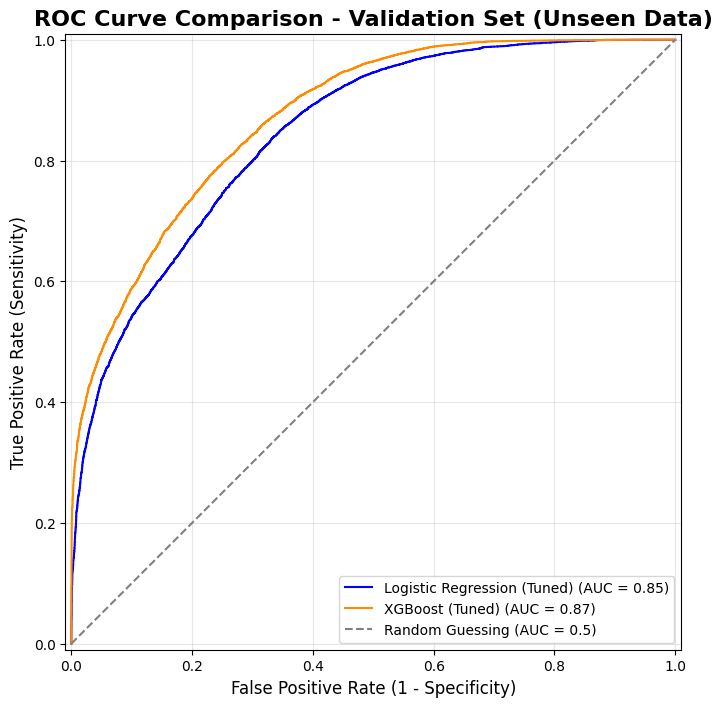

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

# Plot Tuned Logistic Regression (Evaluated on Validation Set)
RocCurveDisplay.from_estimator(
    best_log_reg,
    X_val,
    y_val,
    name="Logistic Regression (Tuned)",
    color="blue",
    ax=ax
)

# Plot Tuned XGBoost (Evaluated on Validation Set)
RocCurveDisplay.from_estimator(
    best_xgb_model,
    X_val,
    y_val,
    name="XGBoost (Tuned)",
    color="darkorange",
    ax=ax
)

# Add the "Random Guessing" baseline (The diagonal line)
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guessing (AUC = 0.5)')

plt.title('ROC Curve Comparison - Validation Set (Unseen Data)', fontsize=16, fontweight='bold')
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

We've successfully built a robust machine learning pipeline from scratch! As you move on to your final projects, keep these rules in mind:

**1. Clean Code & Documentation**  
Data science can get messy quickly. Use informative variable names (e.g., `equipment_value_diff` instead of just `diff` or `x1`). Document your logic with comments and Markdown cells so your teammates, your future self and me :) understand why you made certain decisions.

**2. Strict Train/Test Separation**  
Everything we did today - calculating medians for missing values, figuring out the maximum values for clipping, fitting our `OneHotEncoder`, and fitting our `MinMaxScaler` - was done **STRICTLY on the Training Set**.

**3. What happens to the Test Set?**  
When you are finally ready to evaluate your model on your unseen Test Set, **you do not calculate anything new!** You must apply the exact same pipeline you built for the training data:
* Use the exact same median values to fill missing data in the Test Set.
* Use the exact same `encoder.transform(X_test)` (do NOT `fit` it again).
* Use the exact same `scaler.transform(X_test)` (do NOT `fit` it again).
* Finally, pass the completely preprocessed test data into your trained model to get your answers: `best_xgb_model.predict(X_test_scaled)`.

In order to extract the probabilities and save them as csv file in your project, you could use the following format:

```python
# 1. Generate probabilities
test_probabilities = best_xgb_model.predict_proba(X_test_scaled)[:, 1]

# 2. Create a DataFrame for submission
# Usually, you need an ID column (from the original test_data) and your prediction
submission = pd.DataFrame({
    'id': test_data['id'], # or whatever the unique identifier is
    'round_winner_prob': test_probabilities
})

# 3. Save to CSV
submission.to_csv('final_predictions.csv', index=False)
```


Building a clean, automated preprocessing pipeline will save you hours of debugging.  

# <center>Good luck with your Project!</center>

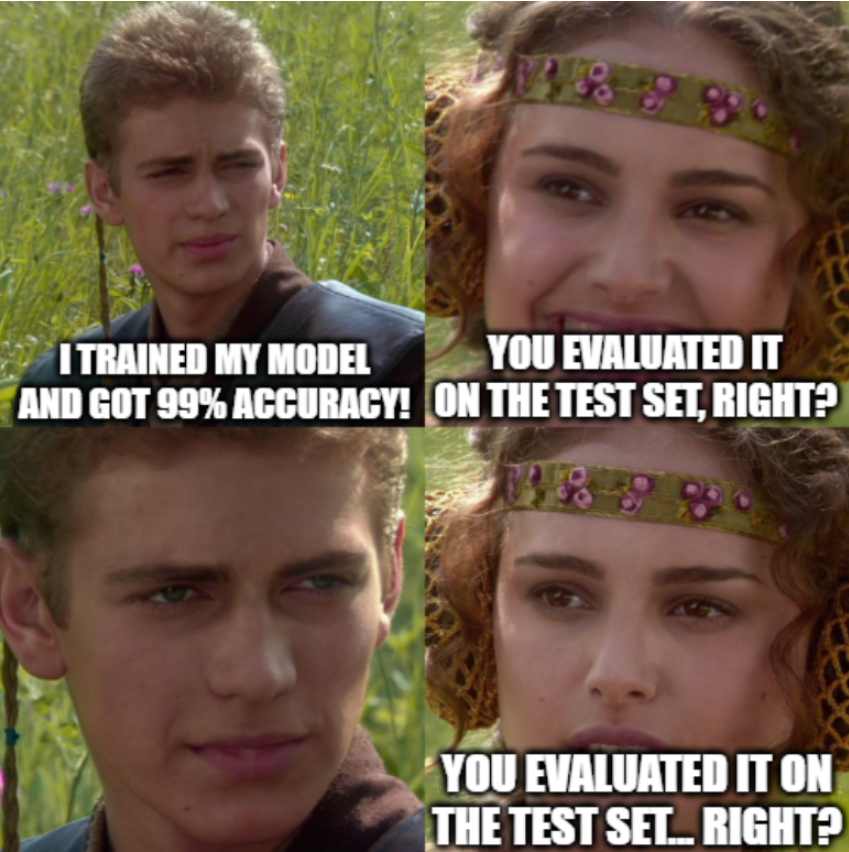